In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
img_escura = files.upload()

Saving imagem_01.png to imagem_01.png
Saving imagem_02.png to imagem_02.png
Saving imagem_03.png to imagem_03.png
Saving imagem_04.png to imagem_04.png
Saving imagem_05.png to imagem_05.png


In [ ]:
def carregar(nome):
    return cv2.imread(nome, cv2.IMREAD_GRAYSCALE)

def hist(img):
    return cv2.calcHist([img], [0], None, [256], [0, 256]).ravel()

def plotar_hist(eixo, img):
    h = hist(img)
    presentes = np.nonzero(h)[0]
    largura = 10 if len(presentes) <= 16 else 1.0
    eixo.bar(presentes, h[presentes], width=largura)
    eixo.set_xlim(-15, 270)
    eixo.set_xlabel("Intensidade")

def comparar(antes, depois, titulo):
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax[0, 0].imshow(antes, cmap="gray", vmin=0, vmax=255)
    ax[0, 0].set_title("Original"); ax[0, 0].set_axis_off()
    ax[0, 1].imshow(depois, cmap="gray", vmin=0, vmax=255)
    ax[0, 1].set_title(titulo); ax[0, 1].set_axis_off()
    plotar_hist(ax[1, 0], antes)
    plotar_hist(ax[1, 1], depois)
    plt.tight_layout(); plt.show()

# Expandindo o constraste da Imagem 01

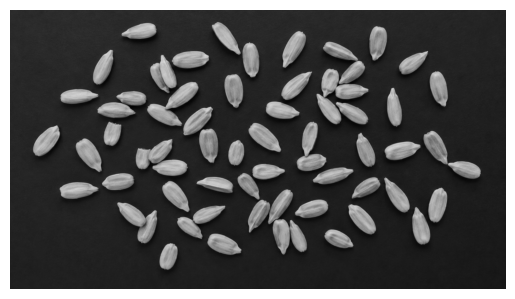

In [ ]:
img_01 = carregar("imagem_01.png")
plt.axis("off")
plt.imshow(img_01, cmap="gray", vmin=0, vmax=255)

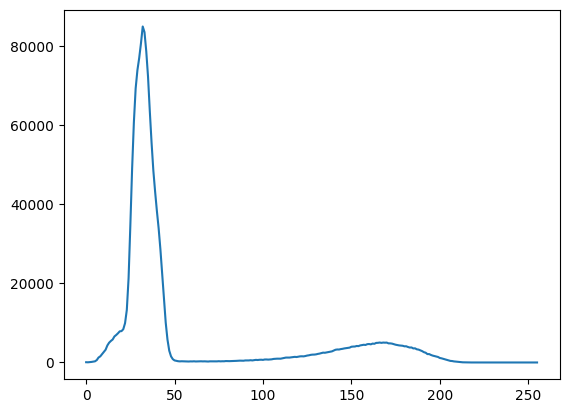

In [ ]:
img_01_hist = hist(img_01)
plt.plot(img_01_hist)

Como a imagem é bem escura, por conta de ter muitos pixels próximo de 0, a redistribuição de intensidade dos pixels é uma boa candidata para melhorar a imagem.

L = 15, H = 188


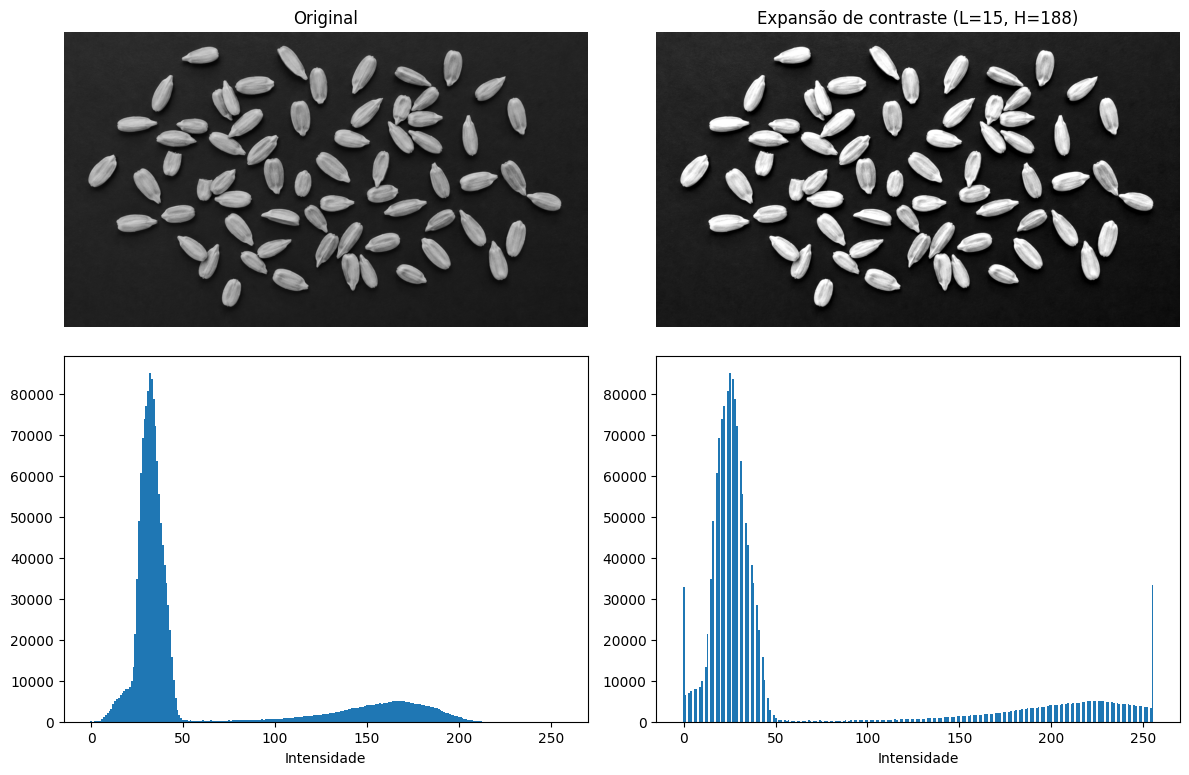

In [ ]:
img_01_exp = cv2.imread("imagem_01.png", cv2.IMREAD_GRAYSCALE)

L, H = np.percentile(img_01_exp, [2, 98])
print(f"L = {L:.0f}, H = {H:.0f}")

expandida = np.clip(img_01_exp.astype(np.float32), L, H)
expandida = np.round((expandida - L) * (255 / (H - L))).astype(np.uint8)

comparar(img_01_exp, expandida, f"Expansão de contraste (L={L:.0f}, H={H:.0f})")

Justificativa: Na imagem original, não é possível ver os detalhes das sementes, por isso, ajustamos o contraste da imagem para poder visualizar melhor os contornos

# Equalizando a Imagem 02

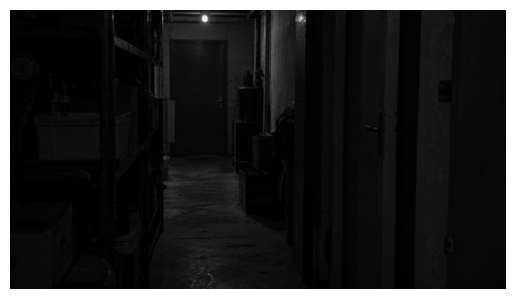

In [ ]:
img_02 = carregar("imagem_02.png")
plt.axis("off")
plt.imshow(img_02, cmap="gray", vmin=0, vmax=255)

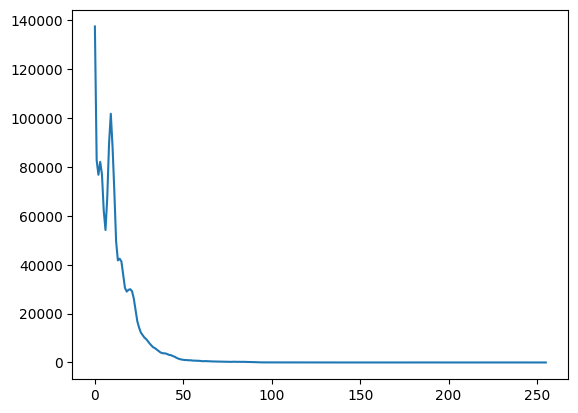

In [ ]:
img_02_hist = hist(img_02)
plt.plot(img_02_hist)

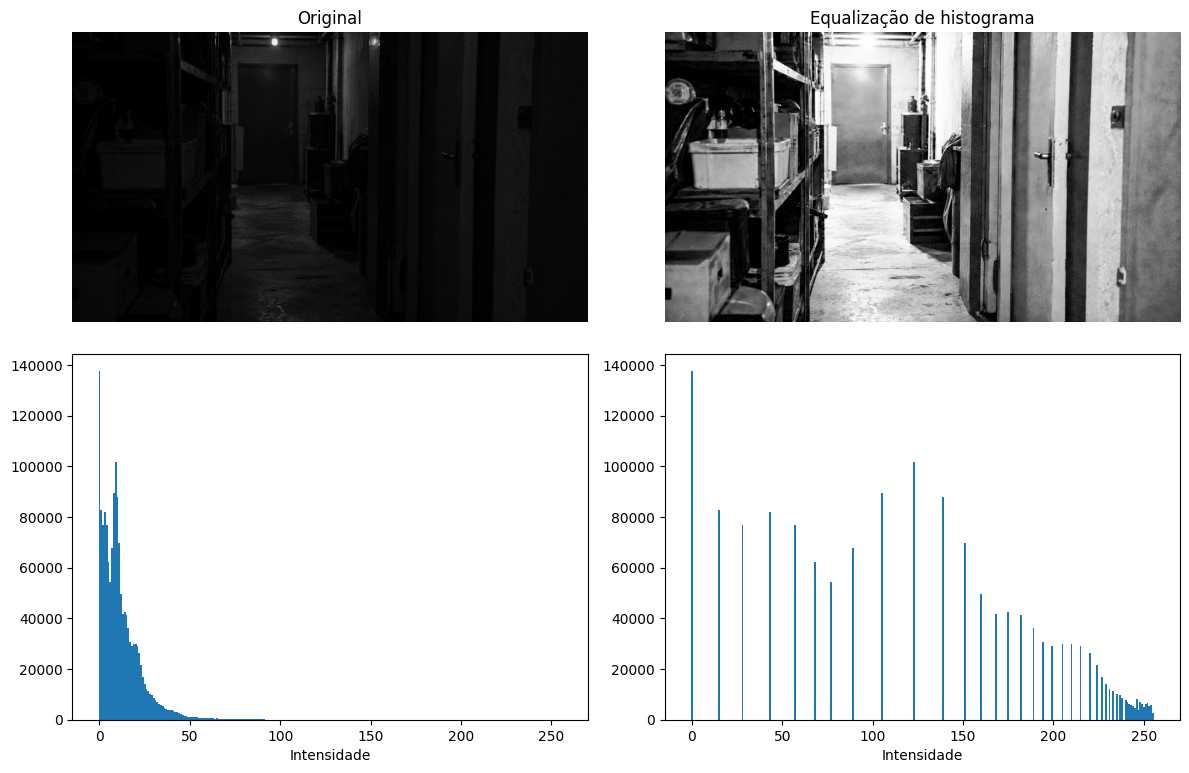

In [ ]:
img_eq = cv2.imread("imagem_02.png", cv2.IMREAD_GRAYSCALE)
equalizada = cv2.equalizeHist(img_eq)

comparar(img_eq, equalizada, "Equalização de histograma")

Justificativa: O histograma da imagem está muito concentrado na cor escura, o que dificulta a leitura da imagem, portanto vamos equilibrar mais os tons da imagem para melhorar a visualização

# Limiarizando a Image 03

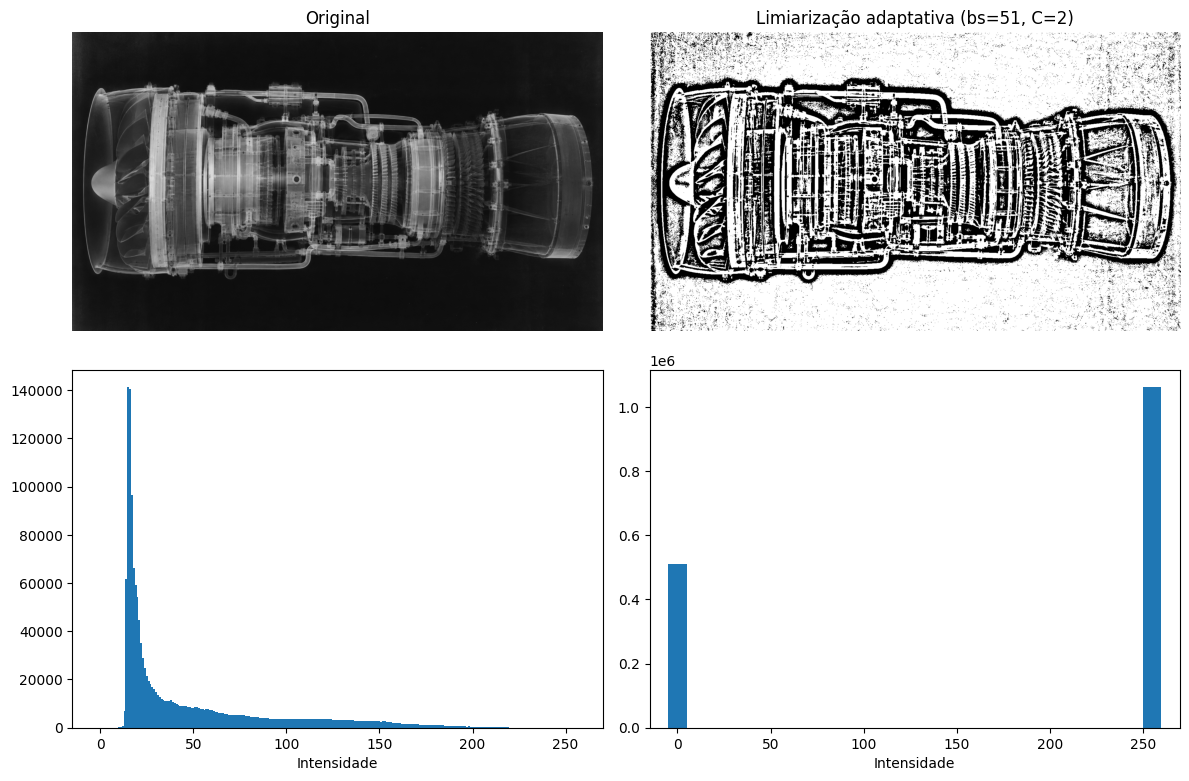

In [ ]:
img_lim = cv2.imread("imagem_03.png", cv2.IMREAD_GRAYSCALE)

adaptativa = cv2.adaptiveThreshold(
    img_lim, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    51,   # blockSize — tamanho da vizinhança, ímpar
    2     # C — constante subtraída da média local
)

comparar(img_lim, adaptativa, "Limiarização adaptativa (bs=51, C=2)")

Justificativa: Na imagem original, os detalhes do motor não são muito visíveis, a limiarização passa os tons de cinza para as extremidades do preto e branco, facilitando a visualização dos detalhes

# Corrigindo o gamma da Imagem 04

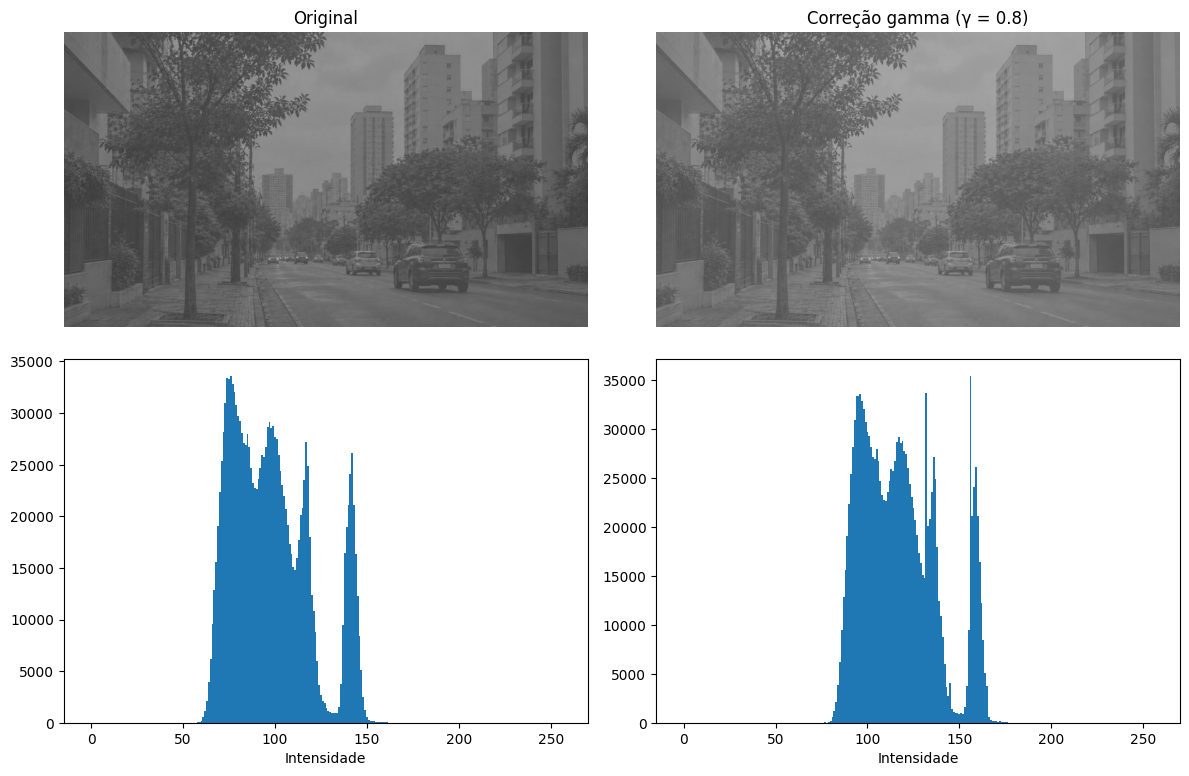

In [ ]:
img_gamma = cv2.imread("imagem_04.png", cv2.IMREAD_GRAYSCALE)

gamma = 0.8
tabela = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
corrigida = cv2.LUT(img_gamma, tabela)

comparar(img_gamma, corrigida, f"Correção gamma (γ = {gamma})")

Justificativa: A imagem está muito clareada, ao ajustarmos o gamma, deslocamos o histograma para a direita, escurecendo a imagem e realçando os detalhes da imagem

# Fazendo o digital negativo da imagem 5

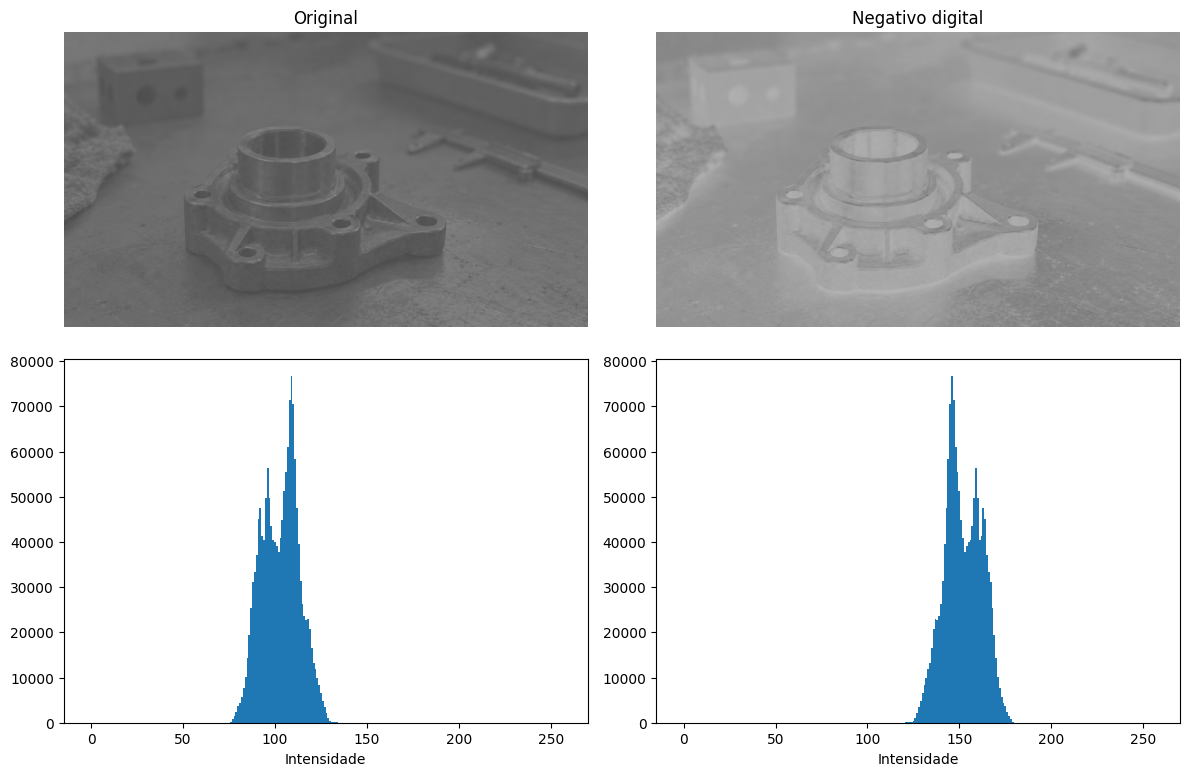

In [ ]:
img_neg = cv2.imread("imagem_05.png", cv2.IMREAD_GRAYSCALE)
negativo = 255 - img_neg

comparar(img_neg, negativo, "Negativo digital")

Justificativa: Na imagem original os detalhes da engrenagem estão pouco aparentes, ao inverter o negativo, podemos enxergar melhor esses detalhes

# Quantizando a imagem 2

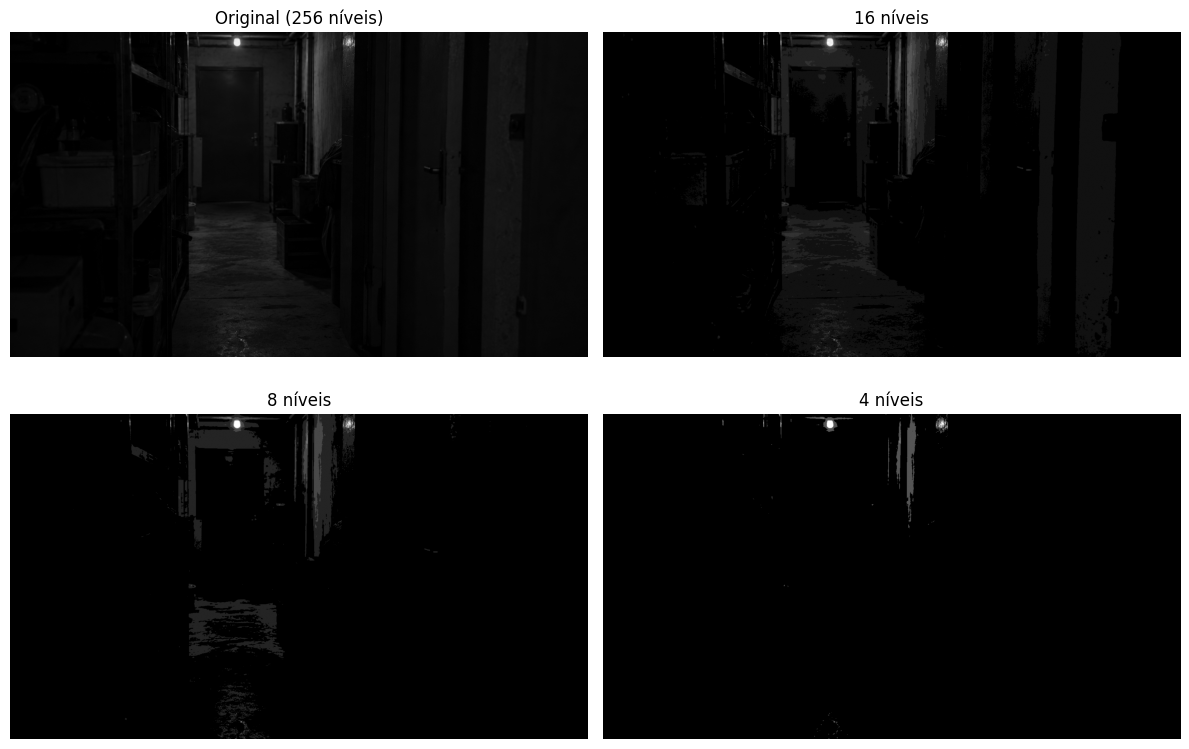

In [ ]:
def quantizar(img, niveis):
    passo = 256 / niveis
    idx = np.floor(img / passo)
    return np.round(idx * (255 / (niveis - 1))).astype(np.uint8)

img_q = cv2.imread("imagem_02.png", cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for eixo, (titulo, imagem) in zip(ax.ravel(), [
    ("Original (256 níveis)", img_q),
    ("16 níveis", quantizar(img_q, 16)),
    ("8 níveis",  quantizar(img_q, 8)),
    ("4 níveis",  quantizar(img_q, 4)),
]):
    eixo.imshow(imagem, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo); eixo.set_axis_off()
plt.tight_layout()
plt.show()

Conforme reduzimos o número de bits, as diferenças entre as imagem se tornam mais perceptíveis. Isso acontece por conta da perda de informação ser maior conforme o nível de intensidade decresce.

# Alunos

## Davi Maciel Cavalcante - 23070028

## João Miguel Semblano Barbosa - 00000092